# TP3 Recuperatorio Grupal

**Modalidad:** grupos de 4 a 5 integrantes.

**Entrega:** notebook completo y ejecutable + corpus en `csv` o `jsonl`.

**Principio de trabajo:** un modelo puede acelerar tareas, pero no reemplaza una buena pregunta, un corpus bien construido ni el criterio humano. En analisis textual sigue valiendo la regla `garbage in, garbage out`.

## Introducción: El sentido del Análisis Computacional de Textos

Antes de ejecutar la primera línea de código, es fundamental comprender qué estamos buscando cuando aplicamos técnicas de Procesamiento de Lenguaje Natural (PLN) en las humanidades digitales y las ciencias sociales computacionales. Los algoritmos no "leen" ni "comprenden" los textos, sino que rastrean y cuantifican patrones lingüísticos. Nuestro trabajo como investigadores no es cederle la interpretación a la máquina, sino usar la computadora como una lente de aumento para volver visibles patrones discursivos.

Para que este enfoque funcione, hay tres dimensiones teórico-prácticas que debemos tener en cuenta:

### 1. El diseño del corpus: "Comparar lo comparable"

El paso analítico más importante no ocurre en el código, sino en la selección del corpus. Si comparamos textos que son inherentemente distintos, por ejemplo una novela romántica contra un manual de física, el algoritmo simplemente nos confirmará lo obvio. El verdadero poder del análisis computacional emerge cuando trabajamos sobre grandes volúmenes de textos que, en principio, parecen idénticos, comparten el mismo género, tratan sobre el mismo tema, ocurren en la misma fecha, pero difieren en una dimensión sutil, como su posición ideológica o su encuadre periodístico. El algoritmo nos permite medir matemáticamente cómo dos discursos construyen mundos diferentes a partir del mismo suceso.

### 2. La trampa del "Garbage In, Garbage Out"

Los modelos de PLN son literales. Si el corpus ingresa sucio, los resultados serán ruido. Un texto natural está lleno de "palabras vacías" (artículos, preposiciones) y verbos genéricos (ser, estar, hacer) que estadísticamente aplastan al vocabulario significativo. Del mismo modo, géneros como el periodismo incluyen vocabulario muy general del género ("nota", "gobierno", "ley") que no aporta valor analítico. El preprocesamiento de los datos, la eliminación de stopwords, la corrección de lemas, la limpieza de ruido estructural, no es una tarea técnica o automática; es una intervención interpretativa y humana crítica sin la cual el análisis resulta inútil.

### 3. Distinción algorítmica: De la frecuencia absoluta a la especificidad (TF-IDF)

Contar qué palabras se repiten más a menudo (frecuencia bruta) rara vez es revelador en grandes volúmenes de texto. La clave del análisis a escala está en encontrar el vocabulario distintivo. Técnicas estadísticas como el TF-IDF penalizan las palabras que todos usan por igual y exaltan aquellas que son exclusivas de un corpus frente a otro. Junto con el análisis de bigramas, pares de palabras que capturan locuciones o conceptos completos, estas métricas no reemplazan la lectura cualitativa: la potencian. Nos indican dónde mirar y qué palabras están funcionando como anclas ideológicas, para que luego nosotros, mediante una lectura atenta, podamos explicar el por qué.

## Que tienen que entregar

- este notebook completo y ejecutable;
- un corpus con **12 textos**: **6 por medio**;
- un mismo tema en ambos medios;
- la columna `grupo_comparacion` con exactamente dos valores posibles;
- una comparacion entre stopwords de `spaCy` y `NLTK`;
- al menos **dos ajustes humanos** del pipeline: uno lexico y uno estructural;
- una comparacion entre `Bag of Words` y `TF-IDF`;
- una lectura de bigramas;
- al menos dos visualizaciones analiticas legibles;
- una vuelta a fragmentos concretos del corpus;
- una conclusion interpretativa y metodologica.

## Que es un corpus

Un corpus no es una pila de textos. Un corpus es una coleccion **finita, explicita, comparable y documentada** de textos seleccionados para responder una pregunta.

Para este trabajo importa especialmente que el corpus:

- responda a una pregunta clara;
- use un criterio de inclusion visible;
- permita una comparacion defendible entre dos grupos;
- conserve trazabilidad de origen;
- haga visibles sus limites.

## Columnas minimas del corpus

- `id`
- `fecha`
- `medio`
- `autor`
- `titulo`
- `url`
- `texto`
- `grupo_comparacion`

En la mayoria de los casos `grupo_comparacion` va a coincidir con los nombres de los dos medios elegidos.

In [1]:
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Elegimos un estilo simple y legible para todos los graficos.
sns.set_theme(style="ticks", context="notebook", palette="colorblind")

# Ampliamos el ancho visible de las columnas textuales.
pd.set_option("display.max_colwidth", 160)

print("Entorno cargado.")

Entorno cargado.


## 0. Configuracion

Guarden el corpus en la misma carpeta que este notebook. Si usan otro nombre o formato, cambien las variables de esta celda.

In [2]:
RUTA_CORPUS = Path("corpus.csv")
FORMATO_CORPUS = "csv"   # opciones: "csv" o "jsonl"

COLUMNA_TEXTO = "texto"
COLUMNA_GRUPO = "grupo_comparacion"
MODELO_SPACY = "es_core_news_md"
TOP_N = 12
VENTANA_FRAGMENTO = 160

print(f"Ruta esperada del corpus: {RUTA_CORPUS}")
print(f"Modelo spaCy esperado: {MODELO_SPACY}")

Ruta esperada del corpus: corpus.csv
Modelo spaCy esperado: es_core_news_md


## 1. Decisiones metodologicas

Agreguen una celda Markdown nueva y respondan, de manera breve, estas cuatro preguntas:

1. Que comparan exactamente.
2. Por que eligieron estos 12 textos y no otros.
3. Que vuelve comparables a ambos medios.
4. Que sesgos o limites iniciales ven en el corpus.

* Se busca comparar el vocabulario de dos medios al referirse a la Reforma laboral. Suponemos que un medio utilizará términos en referencia al empleador y otro con preferencia al empleado.
* Se eligió este corpus en base a la temática y se buscó artículos que hayan sido publicados dentro de un período de tiempo acotado. Entre febrero y abril del 2026. Se seleccionaron textos de diferentes autores.
* Cada grupo esta compuesto por artículos referentes a la misma temática, en el mismo período de tiempo. Se tomaron 6 artículos por medio.
* El corpus tiene solamente 12 texto, 6 por artículo, esto puede ser límitante al querer encontrar patrones. Cada texto tiene entre 700 y 1800 palabra. Podría verse un pequeño desbalance en la cantidad de palabras utilizadas en los artículos de La Nación.

## 2. Carga y validacion del corpus

Vamos a trabajar en pasos separados. La idea es que se vea con claridad que valida cada bloque.

In [3]:
COLUMNAS_REQUERIDAS = [
    "id",
    "fecha",
    "medio",
    "autor",
    "titulo",
    "url",
    COLUMNA_TEXTO,
    COLUMNA_GRUPO,
]

# Primero revisamos si el archivo existe.
archivo_existe = RUTA_CORPUS.exists()

if not archivo_existe:
    raise FileNotFoundError(
        f"No se encontro {RUTA_CORPUS}. Guardalo en esta carpeta o corregi RUTA_CORPUS."
    )

# Despues revisamos si el formato declarado es valido.
formatos_validos = ["csv", "jsonl"]

if FORMATO_CORPUS not in formatos_validos:
    raise ValueError("FORMATO_CORPUS debe ser 'csv' o 'jsonl'.")

print("Archivo encontrado y formato declarado correctamente.")

Archivo encontrado y formato declarado correctamente.


In [4]:
# Esta celda solo carga el archivo. Todavia no valida su contenido.
if FORMATO_CORPUS == "csv":
    df = pd.read_csv(RUTA_CORPUS, sep=";")
else:
    df = pd.read_json(RUTA_CORPUS, lines=True)

print(f"Archivo cargado: {len(df)} filas.")

Archivo cargado: 12 filas.


In [5]:
# Miramos una muestra del corpus tal como llego del archivo.
display(df.head())

,id,fecha,medio,autor,titulo,texto,url,grupo_comparacion
0,0,2026-03-06,LA NACION,Melisa Reinhold,Se promulgó la reforma laboral: cuál es el impacto real en la vida de las empresas y de sus empleados,"Se promulgó la reforma laboral: cuál es el impacto real en la vida de las empresas y de sus empleados La nueva ley unifica el cálculo de indemnizaciones, fl...",https://www.lanacion.com.ar/economia/se-promulgo-la-reforma-laboral-cual-es-el-impacto-real-en-la-vida-de-las-empresas-y-de-sus-empleados-nid06032026/,la nación
1,1,2026-02-28,LA NACION,Laura Serra,"Qué es la reforma laboral de Milei que aprobó el Senado: uno por uno, los principales cambios","Qué es la reforma laboral de Milei que aprobó el Senado: uno por uno, los principales cambios El gobierno de Javier Milei consiguió sancionar este viernes l...",https://www.lanacion.com.ar/politica/que-es-la-reforma-laboral-de-milei-que-aprobo-el-senado-uno-por-uno-los-principales-cambios-nid27022026/,la nación
2,2,2026-04-08,LA NACION,Manuela Viñales,Oficial: estos son los impuestos que quedan exentos en la compra de propiedades con la Reforma Laboral,"Hace poco más de un mes, la Ley de Modernización Laboral se publicó en el Boletín Oficial, y de esa manera sus medidas quedaron efectivas. Aunque su eje cen...",https://www.lanacion.com.ar/propiedades/casas-y-departamentos/oficial-estos-son-los-impuestos-que-quedan-exentos-en-la-compra-de-propiedades-con-la-reforma-...,la nación
3,3,2026-02-12,LA NACION,Francisco Jueguen,Contundente respaldo de los empresarios al avance de la reforma laboral en el Congreso,Contundente respaldo de los empresarios al avance de la reforma laboral en el Congreso Cámaras y asociaciones apoyaron la aprobación de la modernización en ...,https://www.lanacion.com.ar/economia/contundente-respaldo-de-los-empresarios-al-avance-de-la-reforma-laboral-en-el-congreso-nid12022026/,la nación
4,4,2026-03-02,LA NACION,NaN,Cuándo entra en vigencia la reforma laboral de Milei que sancionó el Congreso,Cuándo entra en vigencia la reforma laboral de Milei que sancionó el Congreso El proyecto fue aprobado por la Cámara de Diputados y el Senado; ahora resta q...,https://www.lanacion.com.ar/politica/cuando-entra-en-vigencia-la-reforma-laboral-de-milei-que-sanciono-el-congreso-nid02032026/,la nación


In [6]:
# Ahora revisamos si estan todas las columnas obligatorias.
faltantes = []

for columna in COLUMNAS_REQUERIDAS:
    if columna not in df.columns:
        faltantes.append(columna)

if faltantes:
    mensaje = ", ".join(faltantes)
    raise ValueError("Faltan columnas obligatorias: " + mensaje)

print("Columnas obligatorias presentes.")

Columnas obligatorias presentes.


In [7]:
# Revisamos la cantidad total de textos.
cantidad_textos = len(df)

if cantidad_textos != 12:
    raise ValueError("El corpus debe tener exactamente 12 textos.")

print("Cantidad total de textos correcta: 12.")

Cantidad total de textos correcta: 12.


In [8]:
# Limpiamos la columna de grupos antes de contar.
# 'fillna' reemplaza valores vacios.
# 'astype(str)' convierte la columna a texto.
# 'str.strip()' quita espacios al principio y al final.
grupos_limpios = df[COLUMNA_GRUPO]
grupos_limpios = grupos_limpios.fillna("")
grupos_limpios = grupos_limpios.astype(str)
grupos_limpios = grupos_limpios.str.strip()

df[COLUMNA_GRUPO] = grupos_limpios

print("Columna de grupos limpiada.")

Columna de grupos limpiada.


In [9]:
# 'value_counts' cuenta cuantas veces aparece cada valor.
conteos_grupo = df[COLUMNA_GRUPO].value_counts()

grupos_unicos = []
for grupo in conteos_grupo.index.tolist():
    if grupo != "":
        grupos_unicos.append(grupo)

if len(grupos_unicos) != 2:
    raise ValueError("La columna grupo_comparacion debe contener exactamente dos grupos.")

conteos_ordenados = sorted(conteos_grupo.tolist())

if conteos_ordenados != [6, 6]:
    raise ValueError("Cada grupo debe tener exactamente 6 textos.")

print("Cantidad de grupos correcta.")
print("Textos por grupo:")
display(conteos_grupo)

Cantidad de grupos correcta.
Textos por grupo:


,count
grupo_comparacion,
la nación,6
pagina 12,6


In [10]:
# Normalizamos algunas columnas para evitar problemas de espacios o valores vacios.
columnas_textuales = ["id", "medio", "autor", "titulo", "url", COLUMNA_TEXTO, COLUMNA_GRUPO]

for columna in columnas_textuales:
    df[columna] = df[columna].fillna("")
    df[columna] = df[columna].astype(str)
    df[columna] = df[columna].str.strip()

# Convertimos la fecha a un formato temporal estandar.
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

print("Columnas normalizadas.")

Columnas normalizadas.


In [11]:
# Este patron busca secuencias de letras de largo 2 o mas.
# Nos sirve para una cuenta aproximada de palabras.
patron_palabras = r"\b[^\W\d_]{2,}\b"

coincidencias_por_texto = df[COLUMNA_TEXTO].str.findall(patron_palabras)
cantidades_palabras = coincidencias_por_texto.str.len()

df["num_palabras"] = cantidades_palabras

print(f"Documentos cargados: {len(df)}")
print("Grupos detectados:")
display(pd.Series(grupos_unicos))

columnas_mostrar = ["id", "fecha", "medio", "autor", "titulo", COLUMNA_GRUPO, "num_palabras"]
display(df[columnas_mostrar])

Documentos cargados: 12
Grupos detectados:


,0
0,la nación
1,pagina 12


,id,fecha,medio,autor,titulo,grupo_comparacion,num_palabras
0,0,2026-03-06,LA NACION,Melisa Reinhold,Se promulgó la reforma laboral: cuál es el impacto real en la vida de las empresas y de sus empleados,la nación,1019
1,1,2026-02-28,LA NACION,Laura Serra,"Qué es la reforma laboral de Milei que aprobó el Senado: uno por uno, los principales cambios",la nación,1837
2,2,2026-04-08,LA NACION,Manuela Viñales,Oficial: estos son los impuestos que quedan exentos en la compra de propiedades con la Reforma Laboral,la nación,898
3,3,2026-02-12,LA NACION,Francisco Jueguen,Contundente respaldo de los empresarios al avance de la reforma laboral en el Congreso,la nación,1624
4,4,2026-03-02,LA NACION,,Cuándo entra en vigencia la reforma laboral de Milei que sancionó el Congreso,la nación,1824
5,5,2026-02-12,LA NACION,Laura Serra,"Reforma laboral completa: artículo por artículo, así es el proyecto de Milei que aprobó el Senado",la nación,1440
6,6,2026-02-13,Página|12,Celeste del Bianco,Todos los derechos con los que arrasa la reforma laboral de Milei,pagina 12,1152
7,7,2026-03-06,Página|12,Victor Wolf,"Milei promulgó su reforma laboral: uno por uno, todos los derechos que pierden los trabajadores",pagina 12,1338
8,8,2026-02-22,Página|12,Hernán Letcher,El futuro del trabajo con la reforma laboral,pagina 12,1455
9,9,2026-03-07,Página|12,Mara Pedrazzoli,El impacto de la reforma laboral,pagina 12,782


## 3. Auditoria del corpus

Antes de interpretar, conviene hacer una auditoria basica del recorte. En un corpus chico, los desbalances importan mucho.

In [12]:
# Armamos una tabla breve con metricas generales del corpus.
metricas = ["documentos", "palabras aproximadas", "promedio por texto"]
valores = []

valores.append(len(df))
valores.append(int(df["num_palabras"].sum()))
valores.append(round(float(df["num_palabras"].mean()), 1))

resumen_corpus = pd.DataFrame({"metrica": metricas, "valor": valores})
display(resumen_corpus)

,metrica,valor
0,documentos,12.0
1,palabras aproximadas,16140.0
2,promedio por texto,1345.0


In [13]:
# 'groupby' agrupa filas segun una columna.
# En este caso agrupamos por medio para comparar las dos series.
agrupado = df.groupby(COLUMNA_GRUPO)

# 'agg' sirve para resumir cada grupo con una o varias operaciones.
resumen_por_grupo = agrupado.agg(
    documentos=("id", "count"),
    palabras_totales=("num_palabras", "sum"),
    promedio_palabras=("num_palabras", "mean"),
)

# 'reset_index' devuelve el indice a una columna comun.
resumen_por_grupo = resumen_por_grupo.reset_index()

# 'sort_values' ordena las filas.
resumen_por_grupo = resumen_por_grupo.sort_values(COLUMNA_GRUPO)

display(resumen_por_grupo.round(1))

,grupo_comparacion,documentos,palabras_totales,promedio_palabras
0,la nación,6,8642,1440.3
1,pagina 12,6,7498,1249.7


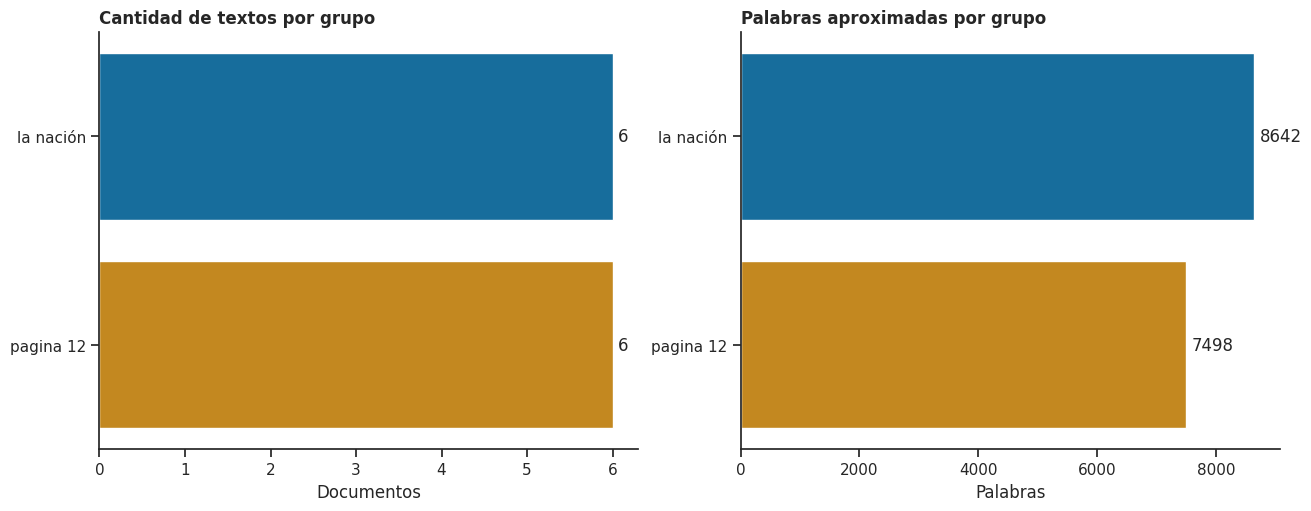

In [14]:
# Grafico 1: cantidad de textos por grupo.
# Grafico 2: cantidad aproximada de palabras por grupo.
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

sns.barplot(
    data=resumen_por_grupo,
    x="documentos",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    legend=False,
    ax=axes[0],
)

axes[0].set_title("Cantidad de textos por grupo", loc="left", fontweight="bold")
axes[0].set_xlabel("Documentos")
axes[0].set_ylabel("")

for contenedor in axes[0].containers:
    axes[0].bar_label(contenedor, fmt="%.0f", padding=4)

sns.barplot(
    data=resumen_por_grupo,
    x="palabras_totales",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    legend=False,
    ax=axes[1],
)

axes[1].set_title("Palabras aproximadas por grupo", loc="left", fontweight="bold")
axes[1].set_xlabel("Palabras")
axes[1].set_ylabel("")

for contenedor in axes[1].containers:
    axes[1].bar_label(contenedor, fmt="%.0f", padding=4)

sns.despine()
plt.show()

Agreguen una celda Markdown nueva y anoten si ven desbalances de longitud, autoria, fechas o recorte.

Se observa que los artículos de La Nación suman mas palabras (8642 vs 7498). La diferencia de aproximadamente 1100 palabras genera un pequeño desbalance entre ambos grupos. Ese desbalance no es significativo.
Todos los artículos fueron publicados entre febrero y abril del 2026.

## 4. Inspeccion con spaCy (`es_core_news_md`)

En esta parte no basta con ejecutar. Miren como el modelo tokeniza, lematiza, etiqueta y reconoce entidades en su corpus.

**Vocabulario de esta seccion**

- **pipeline**: secuencia de operaciones que el modelo aplica al texto;
- **token**: unidad de texto separada por el modelo;
- **lema**: forma base de una palabra;
- **POS**: categoria gramatical general;
- **dependencia**: relacion sintactica entre palabras;
- **entidad**: nombre propio, organizacion, lugar u otra expresion relevante;
- **rasgo morfologico**: informacion como numero, genero o persona.

In [15]:
!python -m spacy download es_core_news_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 17.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [16]:
try:
    import spacy
    from spacy.matcher import Matcher
    nlp = spacy.load(MODELO_SPACY)
except Exception as error:
    raise RuntimeError(
        "No se pudo cargar spaCy. Instalen el modelo con: python -m spacy download es_core_news_md"
    ) from error

# Ajustamos algunas stopwords que pueden resultar utiles en corpus en espanol.
nlp.vocab["él"].is_stop = True
nlp.vocab["ella"].is_stop = True

print(f"Modelo cargado: {MODELO_SPACY}")
print("Pipeline activo:")
display(pd.Series(nlp.pipe_names))

Modelo cargado: es_core_news_md
Pipeline activo:


,0
0,tok2vec
1,morphologizer
2,parser
3,attribute_ruler
4,lemmatizer
5,ner


In [17]:
# 'pipe' procesa muchos textos de una vez.
# Lo usamos porque todo el corpus pasa por el mismo pipeline.
textos_corpus = df[COLUMNA_TEXTO].tolist()
docs_base = list(nlp.pipe(textos_corpus))

print(f"Documentos procesados con spaCy: {len(docs_base)}")

Documentos procesados con spaCy: 12


In [18]:
def normalizar_lemma(token):
    # 'lemma_' es la forma base de una palabra segun el modelo.
    lema = token.lemma_.strip().lower()

    # A veces spaCy devuelve un lema vacio o '-PRON-'.
    # En esos casos usamos la forma original en minuscula.
    if not lema or lema == "-pron-":
        lema = token.text.lower()

    return lema

texto_muestra = df.loc[0, COLUMNA_TEXTO]
fragmento = texto_muestra[:350]
doc_fragmento = nlp(fragmento)

registros_tokens = []

for indice, token in enumerate(doc_fragmento):
    if indice >= 25:
        break

    if token.is_space:
        continue

    # 'pos_' es la categoria gramatical general.
    # 'tag_' es una etiqueta mas especifica.
    # 'dep_' muestra la relacion sintactica.
    # 'morph' guarda rasgos como numero, genero o persona.
    registro_token = {
        "token": token.text,
        "lemma": normalizar_lemma(token),
        "pos": token.pos_,
        "tag": token.tag_,
        "dep": token.dep_,
        "ent": token.ent_type_ if token.ent_type_ else "-",
        "morph": str(token.morph) if str(token.morph) else "-",
    }
    registros_tokens.append(registro_token)

tabla_tokens = pd.DataFrame(registros_tokens)
display(tabla_tokens)

,token,lemma,pos,tag,dep,ent,morph
0,Se,él,PRON,PRON,expl:pass,-,Case=Acc|Person=3|PrepCase=Npr|PronType=Prs|Reflex=Yes
1,promulgó,promulgar,VERB,VERB,ROOT,-,Mood=Ind|Number=Sing|Person=3|Tense=Past|VerbForm=Fin
2,la,el,DET,DET,det,-,Definite=Def|Gender=Fem|Number=Sing|PronType=Art
3,reforma,reforma,NOUN,NOUN,nsubj,-,Gender=Fem|Number=Sing
4,laboral,laboral,ADJ,ADJ,amod,-,Number=Sing
5,:,:,PUNCT,PUNCT,punct,-,PunctType=Colo
6,cuál,cuál,PRON,PRON,nsubj,-,"Number=Sing|PronType=Int,Rel"
7,es,ser,AUX,AUX,cop,-,Mood=Ind|Number=Sing|Person=3|Tense=Pres|VerbForm=Fin
8,el,el,DET,DET,det,-,Definite=Def|Gender=Masc|Number=Sing|PronType=Art
9,impacto,impacto,NOUN,NOUN,acl,-,Gender=Masc|Number=Sing


In [19]:
# Esta funcion arma una tabla de frecuencias para una familia de etiquetas.
def tabla_etiquetas(docs, atributo, incluir_vacios=False):
    contador = Counter()

    for doc in docs:
        for token in doc:
            if token.is_space:
                continue

            valor = getattr(token, atributo)

            if not valor and not incluir_vacios:
                continue

            if not valor:
                valor = "-"

            contador[valor] += 1

    filas = []

    for etiqueta, frecuencia in contador.most_common():
        descripcion = "-"

        if etiqueta != "-":
            explicacion = spacy.explain(etiqueta)
            if explicacion:
                descripcion = explicacion

        fila = {
            "etiqueta": etiqueta,
            "descripcion": descripcion,
            "frecuencia": frecuencia,
        }
        filas.append(fila)

    return pd.DataFrame(filas)

In [20]:
tabla_pos = tabla_etiquetas(docs_base, "pos_")

print("POS detectadas")
display(tabla_pos.head(15))

POS detectadas


,etiqueta,descripcion,frecuencia
0,NOUN,noun,4178
1,ADP,adposition,3066
2,DET,determiner,2795
3,PUNCT,punctuation,2332
4,VERB,verb,1668
5,ADJ,adjective,1523
6,PROPN,proper noun,877
7,PRON,pronoun,864
8,CCONJ,coordinating conjunction,570
9,ADV,adverb,543


In [21]:
tabla_tag = tabla_etiquetas(docs_base, "tag_")

print("TAG detectadas")
display(tabla_tag.head(15))

TAG detectadas


,etiqueta,descripcion,frecuencia
0,NOUN,noun,4178
1,ADP,adposition,3066
2,DET,determiner,2795
3,PUNCT,punctuation,2332
4,VERB,verb,1668
5,ADJ,adjective,1523
6,PROPN,proper noun,877
7,PRON,pronoun,864
8,CCONJ,coordinating conjunction,570
9,ADV,adverb,543


In [22]:
tabla_dep = tabla_etiquetas(docs_base, "dep_")

print("Dependencias detectadas")
display(tabla_dep.head(15))

Dependencias detectadas


/usr/local/lib/python3.12/dist-packages/spacy/glossary.py:20: UserWarning: [W118] Term 'expl:pass' not found in glossary. It may however be explained in documentation for the corpora used to train the language. Please check `nlp.meta["sources"]` for any relevant links.
  warnings.warn(Warnings.W118.format(term=term))
/usr/local/lib/python3.12/dist-packages/spacy/glossary.py:20: UserWarning: [W118] Term 'expl:pv' not found in glossary. It may however be explained in documentation for the corpora used to train the language. Please check `nlp.meta["sources"]` for any relevant links.
  warnings.warn(Warnings.W118.format(term=term))
/usr/local/lib/python3.12/dist-packages/spacy/glossary.py:20: UserWarning: [W118] Term 'expl:impers' not found in glossary. It may however be explained in documentation for the corpora used to train the language. Please check `nlp.meta["sources"]` for any relevant links.
  warnings.warn(Warnings.W118.format(term=term))


,etiqueta,descripcion,frecuencia
0,det,determiner,2817
1,case,case marking,2719
2,punct,punctuation,2336
3,nmod,modifier of nominal,1496
4,amod,adjectival modifier,1295
5,nsubj,nominal subject,1139
6,obj,object,1107
7,obl,oblique nominal,726
8,ROOT,root,710
9,conj,conjunct,642


In [23]:
tabla_ent = tabla_etiquetas(docs_base, "ent_type_")

print("Entidades detectadas")
display(tabla_ent.head(15))

Entidades detectadas


,etiqueta,descripcion,frecuencia
0,MISC,"Miscellaneous entities, e.g. events, nationalities, products or works of art",1371
1,ORG,"Companies, agencies, institutions, etc.",338
2,LOC,"Non-GPE locations, mountain ranges, bodies of water",190
3,PER,Named person or family.,177


In [24]:
registros_entidades = []

for doc_id, titulo, grupo, doc in zip(df["id"], df["titulo"], df[COLUMNA_GRUPO], docs_base):
    for ent in doc.ents:
        fila = {
            "id": doc_id,
            "titulo": titulo,
            "grupo": grupo,
            "texto_entidad": ent.text,
            "etiqueta": ent.label_,
        }
        registros_entidades.append(fila)

df_entidades = pd.DataFrame(registros_entidades)

if df_entidades.empty:
    print("No se detectaron entidades en el corpus.")
else:
    print("Muestra de entidades detectadas")
    display(df_entidades.head(20))

Muestra de entidades detectadas


,id,titulo,grupo,texto_entidad,etiqueta
0,0,Se promulgó la reforma laboral: cuál es el impacto real en la vida de las empresas y de sus empleados,la nación,La nueva ley,MISC
1,0,Se promulgó la reforma laboral: cuál es el impacto real en la vida de las empresas y de sus empleados,la nación,Habrá,MISC
2,0,Se promulgó la reforma laboral: cuál es el impacto real en la vida de las empresas y de sus empleados,la nación,Los analistas,MISC
3,0,Se promulgó la reforma laboral: cuál es el impacto real en la vida de las empresas y de sus empleados,la nación,Para las compañías,MISC
4,0,Se promulgó la reforma laboral: cuál es el impacto real en la vida de las empresas y de sus empleados,la nación,Hasta el momento,MISC
5,0,Se promulgó la reforma laboral: cuál es el impacto real en la vida de las empresas y de sus empleados,la nación,Enrique Stile,PER
6,0,Se promulgó la reforma laboral: cuál es el impacto real en la vida de las empresas y de sus empleados,la nación,Marval O’Farrell Mairal,PER
7,0,Se promulgó la reforma laboral: cuál es el impacto real en la vida de las empresas y de sus empleados,la nación,Cualquiera,MISC
8,0,Se promulgó la reforma laboral: cuál es el impacto real en la vida de las empresas y de sus empleados,la nación,Para la calificadora de riesgo,MISC
9,0,Se promulgó la reforma laboral: cuál es el impacto real en la vida de las empresas y de sus empleados,la nación,Moody’s Ratings,ORG


In [25]:
if df_entidades.empty:
    tabla_tipos_entidad = pd.DataFrame(columns=["grupo", "etiqueta", "frecuencia"])
else:
    agrupado_tipos = df_entidades.groupby(["grupo", "etiqueta"])
    tabla_tipos_entidad = agrupado_tipos.size()
    tabla_tipos_entidad = tabla_tipos_entidad.reset_index(name="frecuencia")
    tabla_tipos_entidad = tabla_tipos_entidad.sort_values(["grupo", "frecuencia"], ascending=[True, False])

print("Tipos de entidad por grupo")
display(tabla_tipos_entidad)

Tipos de entidad por grupo


,grupo,etiqueta,frecuencia
1,la nación,MISC,222
2,la nación,ORG,92
0,la nación,LOC,47
3,la nación,PER,47
5,pagina 12,MISC,175
6,pagina 12,ORG,74
4,pagina 12,LOC,71
7,pagina 12,PER,63


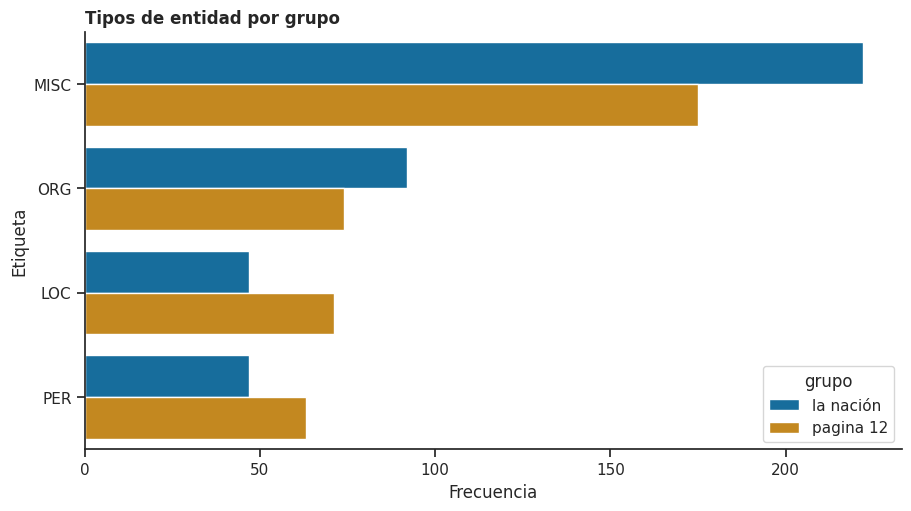

In [26]:
if df_entidades.empty:
    print("No hay entidades para graficar.")
else:
    fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
    sns.barplot(
        data=tabla_tipos_entidad,
        x="frecuencia",
        y="etiqueta",
        hue="grupo",
        ax=ax,
    )
    ax.set_title("Tipos de entidad por grupo", loc="left", fontweight="bold")
    ax.set_xlabel("Frecuencia")
    ax.set_ylabel("Etiqueta")
    sns.despine(ax=ax)
    plt.show()

In [27]:
if df_entidades.empty:
    tabla_entidades_concretas = pd.DataFrame(columns=["grupo", "texto_entidad", "etiqueta", "frecuencia"])
    top_entidades_concretas = tabla_entidades_concretas.copy()
else:
    agrupado_entidades = df_entidades.groupby(["grupo", "texto_entidad", "etiqueta"])
    tabla_entidades_concretas = agrupado_entidades.size()
    tabla_entidades_concretas = tabla_entidades_concretas.reset_index(name="frecuencia")
    tabla_entidades_concretas = tabla_entidades_concretas.sort_values(["grupo", "frecuencia"], ascending=[True, False])

    agrupado_top_entidades = tabla_entidades_concretas.groupby("grupo")
    top_entidades_concretas = agrupado_top_entidades.head(10)

print("Entidades concretas por grupo")
display(top_entidades_concretas)

Entidades concretas por grupo


,grupo,texto_entidad,etiqueta,frecuencia
202,la nación,Senado,ORG,11
228,la nación,la Argentina,LOC,7
105,la nación,Justicia,ORG,6
120,la nación,La reforma,MISC,6
196,la nación,Régimen de Incentivo,MISC,6
80,la nación,FAL,MISC,5
98,la nación,Impuesto a las Ganancias,MISC,5
218,la nación,UIA,ORG,5
17,la nación,Argentina,LOC,4
19,la nación,Asimismo,MISC,4


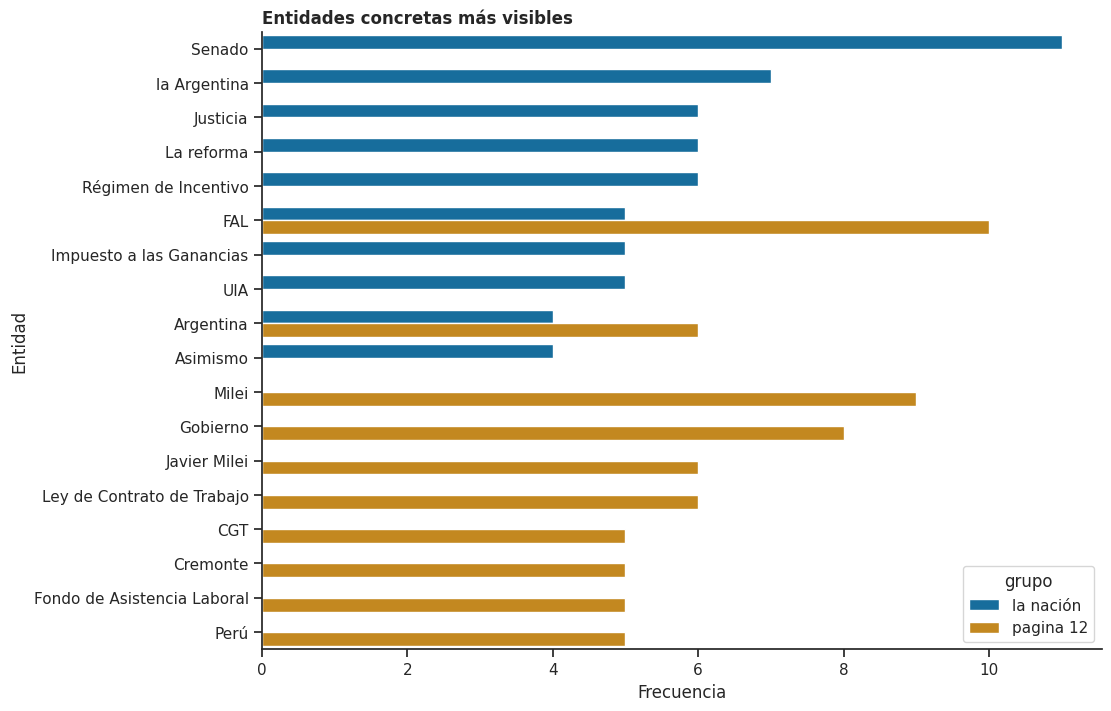

In [28]:
if df_entidades.empty:
    print("No hay entidades concretas para graficar.")
else:
    fig, ax = plt.subplots(figsize=(11, 7), constrained_layout=True)
    sns.barplot(
        data=top_entidades_concretas,
        x="frecuencia",
        y="texto_entidad",
        hue="grupo",
        ax=ax,
    )
    ax.set_title("Entidades concretas más visibles", loc="left", fontweight="bold")
    ax.set_xlabel("Frecuencia")
    ax.set_ylabel("Entidad")
    sns.despine(ax=ax)
    plt.show()

In [29]:
# Top 20 entidades por tipo (MISC, ORG, PER, LOC)

from collections import Counter

def top_entidades_por_tipo(docs, top_n=20):
    entidades_por_tipo = {
        "MISC": [],
        "ORG": [],
        "PER": [],
        "LOC": [],
    }

    for doc in docs:
        for ent in doc.ents:
            if ent.label_ in entidades_por_tipo:
                entidades_por_tipo[ent.label_].append(ent.text.strip())

    for tipo, lista_entidades in entidades_por_tipo.items():
        print(f"\nTop {top_n} entidades para {tipo}")

        contador = Counter(lista_entidades)
        tabla = pd.DataFrame(
            contador.most_common(top_n),
            columns=["entidad", "frecuencia"]
        )

        display(tabla)
    return  entidades_por_tipo


# Ejecutar
entidades_por_tipo = top_entidades_por_tipo(docs_base, top_n=20)


Top 20 entidades para MISC


,entidad,frecuencia
0,FAL,15
1,La reforma,7
2,Régimen de Incentivo,6
3,Ley de Contrato de Trabajo,6
4,No,5
5,El Gobierno,5
6,Impuesto a las Ganancias,5
7,Asimismo,4
8,El proyecto,4
9,Boletín Oficial,4



Top 20 entidades para ORG


,entidad,frecuencia
0,Senado,16
1,Justicia,9
2,Fondo de Asistencia Laboral,6
3,Congreso,6
4,Gobierno,5
5,UIA,5
6,CGT,5
7,Cámara de Diputados,4
8,RIFL,4
9,Comisión Nacional de Valores,3



Top 20 entidades para PER


,entidad,frecuencia
0,Milei,13
1,Javier Milei,9
2,Domínguez,4
3,Ganancias,4
4,LA NACION,4
5,Enfermedades,3
6,Permanece,3
7,Matías Cremonte,3
8,Campos,3
9,Ottaviano,3



Top 20 entidades para LOC


,entidad,frecuencia
0,Gobierno,12
1,Argentina,10
2,la Argentina,9
3,Cremonte,5
4,Perú,5
5,Ciudad de Buenos Aires,4
6,Anses,3
7,Registro de Empleadores,3
8,Sanciones Laborales,3
9,Entre,3


In [30]:
# vemos las entidades reconocidas como MISC
set(entidades_por_tipo['MISC'])

{'A diferencia de lo que ocurre con la compraventa',
 'ABA',
 'Adeba',
 'Aefip',
 'Afecta el artículo 14 bis de la',
 'Afirmaron',
 'Ahora',
 'Al desaparecer este artículo',
 'Algunos de los puntos',
 'Antigüedad',
 'Asimismo',
 'Así, el empleo',
 'Bajo',
 'Boletín Oficial',
 'Cajas sindicales',
 'Carta Magna',
 'Con el banco de horas',
 'Con el gobierno de Duhalde',
 'Con la nueva ley',
 'Con poco más de 200 artículos',
 'Convenciones Colectivas de Trabajo',
 'Crea',
 'Cualquiera',
 'Cuáles',
 'Código Civil',
 'Cómo',
 'DNU',
 'De esta manera',
 'De hecho',
 'Debe',
 'Decreto de Necesidad y Urgencia',
 'Dentro de este impuesto',
 'Derechos y Deberes',
 'Despidos',
 'Dicho en criollo',
 'Diputados',
 'Disolución de la Justicia Nacional del Trabajo',
 'Ejes centrales de la iniciativa 1',
 'El Congreso',
 'El FAL',
 'El Gobierno',
 'El abogado advierte sobre la dificultad',
 'El banco de horas',
 'El costo fiscal alcanza 0,275 puntos del PBI',
 'El desafío es claro',
 'El efecto de estas

In [31]:
# vemos las entidades reconocidas como ORG
set(entidades_por_tipo['ORG'])

{'ABA',
 'AEA',
 'Abogadas Laboralistas',
 'Al',
 'Algo',
 'AmCham',
 'Anses',
 'Asociación Empresaria Argentina',
 'Asociación Latinoamericana de Abogados',
 'Asociación Latinoamericana de Abogados Laboralistas.',
 'Asociación de Empleados Fiscales',
 'Bolsa de Comercio',
 'CAC',
 'CGT',
 'CTA Autónoma',
 'Comisión Nacional de Valores',
 'Comisión de Legislación del Trabajo de la Cámara de Diputados',
 'Congreso',
 'Congreso Cámaras',
 'Consejo de Mayo',
 'Constitución Nacional',
 'Convenios Colectivos',
 'Corte Suprema',
 'Cámara Nacional de Apelaciones del Trabajo-',
 'Cámara de Comercio y Servicios',
 'Cámara de Diputados',
 'Derecho Colectivo del Trabajo de la UBA',
 'Estamos',
 'FAL',
 'FATE',
 'Fondo',
 'Fondo de Asistencia Laboral',
 'Fondo de Cese Laboral',
 'Fondo de Indemnizaciones',
 'Forbes',
 'Ganancias',
 'Gobierno',
 'Gobierno-',
 'Gobierno.',
 'Impuesto',
 'Instituto Argentino de Análisis Fiscal',
 'Justicia',
 'Justicia Nacional de Trabajo',
 'Justicia Nacional del Tr

In [33]:
# frecuencia de cada entidad ORG en el corpus
counter_org = Counter()

for doc in docs_base:
    for ent in doc.ents:
        if ent.label_ == "ORG":
            counter_org[ent.text] += 1

# mostrar como dataframe ordenado por frecuencia
df_org = pd.DataFrame(
    counter_org.most_common(),
    columns=["entidad", "frecuencia"]
)
pd.set_option("display.max_rows", None)
display(df_org)

,entidad,frecuencia
0,Senado,16
1,Justicia,9
2,Fondo de Asistencia Laboral,6
3,Congreso,6
4,Gobierno,5
5,UIA,5
6,CGT,5
7,Cámara de Diputados,4
8,RIFL,4
9,Comisión Nacional de Valores,3


In [34]:
def tabla_morph(docs):
    contador = Counter()

    for doc in docs:
        for token in doc:
            if token.is_space:
                continue

            rasgos = str(token.morph)

            if not rasgos:
                rasgos = "-"

            contador[rasgos] += 1

    filas = []

    for rasgos, frecuencia in contador.most_common():
        filas.append({"morph": rasgos, "frecuencia": frecuencia})

    return pd.DataFrame(filas)

tabla_morf = tabla_morph(docs_base)

print("Rasgos morfologicos detectados")
display(tabla_morf.head(15))

Rasgos morfologicos detectados


,morph,frecuencia
0,-,5158
1,Gender=Masc|Number=Sing,1417
2,Gender=Fem|Number=Sing,1369
3,Definite=Def|Gender=Masc|Number=Sing|PronType=Art,1021
4,PunctType=Comm,906
5,Gender=Masc|Number=Plur,902
6,Definite=Def|Gender=Fem|Number=Sing|PronType=Art,788
7,Gender=Fem|Number=Plur,708
8,Mood=Ind|Number=Sing|Person=3|Tense=Pres|VerbForm=Fin,677
9,PunctType=Peri,656


Agreguen una celda Markdown nueva y registren al menos **dos limites o errores** que observen en el pipeline de `spaCy` sobre su corpus.

## 5. Stopwords: `spaCy` vs `NLTK`

Comparen ambos enfoques antes de decidir. No existe una lista universalmente correcta.

**Vocabulario de esta seccion**

- **stopword**: palabra muy frecuente que muchas veces aporta poco para diferenciar textos;
- **lista base**: conjunto inicial de stopwords que tomamos de una libreria;
- **lista ajustada**: lista base modificada segun las necesidades del corpus.

In [35]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)

stopwords_nltk = set(stopwords.words("spanish"))
stopwords_nltk.add("él")

stopwords_spacy = set(nlp.Defaults.stop_words)
stopwords_spacy.add("él")

print(f"Stopwords spaCy: {len(stopwords_spacy)}")
print(f"Stopwords NLTK: {len(stopwords_nltk)}")

Stopwords spaCy: 521
Stopwords NLTK: 313


In [36]:
# Comparamos algunas diferencias entre listas.
solo_spacy = stopwords_spacy - stopwords_nltk
solo_nltk = stopwords_nltk - stopwords_spacy

lista_solo_spacy = list(solo_spacy)
lista_solo_spacy = sorted(lista_solo_spacy)
muestra_solo_spacy = lista_solo_spacy[:20]

lista_solo_nltk = list(solo_nltk)
lista_solo_nltk = sorted(lista_solo_nltk)
muestra_solo_nltk = lista_solo_nltk[:20]

print("Ejemplos de palabras que aparecen solo en spaCy:")
display(pd.Series(muestra_solo_spacy))

print("Ejemplos de palabras que aparecen solo en NLTK:")
display(pd.Series(muestra_solo_nltk))

Ejemplos de palabras que aparecen solo en spaCy:


,0
0,acuerdo
1,adelante
2,ademas
3,además
4,afirmó
5,agregó
6,ahi
7,ahora
8,ahí
9,alguna


Ejemplos de palabras que aparecen solo en NLTK:


,0
0,erais
1,estabais
2,estabas
3,estad
4,estada
5,estadas
6,estando
7,estaremos
8,estarán
9,estarás


In [37]:
def texto_contenido_desde_doc(doc, stopwords_base):
    # Esta funcion arma una version reducida del texto.
    # Conserva solo palabras alfabeticas que no sean stopwords.
    tokens = []

    for token in doc:
        if not token.is_alpha:
            continue

        forma = token.text.lower()
        lema = normalizar_lemma(token)

        if forma in stopwords_base:
            continue

        if lema in stopwords_base:
            continue

        tokens.append(lema)

    texto_limpio = " ".join(tokens)
    return texto_limpio

In [38]:
textos_spacy_stop = []

for doc in docs_base:
    texto_limpio = texto_contenido_desde_doc(doc, stopwords_spacy)
    textos_spacy_stop.append(texto_limpio)

df["texto_spacy_stop"] = textos_spacy_stop

display(df[["titulo", "texto_spacy_stop"]].head())

,titulo,texto_spacy_stop
0,Se promulgó la reforma laboral: cuál es el impacto real en la vida de las empresas y de sus empleados,promulgar reforma laboral impacto real vida empresa empleado ley unificar cálculo indemnización flexibilizar contratación habilitar cambio organización trab...
1,"Qué es la reforma laboral de Milei que aprobó el Senado: uno por uno, los principales cambios",reforma laboral milei aprobar senado principal cambio gobierno javier milei sancionar viernes reforma laboral trámite revisión senado versión convertir ley ...
2,Oficial: estos son los impuestos que quedan exentos en la compra de propiedades con la Reforma Laboral,mes ley modernización laboral publicar boletín oficial medida quedar efectivo eje central laboral artículo incorporar reforma impositiva relacionado mercado...
3,Contundente respaldo de los empresarios al avance de la reforma laboral en el Congreso,contundente respaldo empresario avance reforma laboral congreso cámaras asociación apoyar aprobación modernización senado afirmar ordenar marco vigente gene...
4,Cuándo entra en vigencia la reforma laboral de Milei que sancionó el Congreso,entrar vigencia reforma laboral milei sancionar congreso proyecto aprobar cámara diputados senado restar promulgar ejecutivo minuto lectura viernes senado a...


In [39]:
for t in df["texto_spacy_stop"]:
    if "él" in t:
        print(t)

promulgar reforma laboral impacto real vida empresa empleado ley unificar cálculo indemnización flexibilizar contratación habilitar cambio organización trabajo analista prever efecto gradual minuto lectura viernes promulgar reforma laboral iniciativa buscar cambiar década relación empresa trabajador único criterio indemnización despido buscar bajar litigiosidad flexibilizar norma crear incentivo impulsar formalización empleo analista coincidir efecto inmediato compañía especialmente pequeño mediano pyme cambio palpabl ley reducción incertidumbre legal hora pagar indemnización momento monto pagar comercio variar depender juez jurisdicción cambio quitar cálculo bono aguinaldo extra unificar criterio calcular indemnización cálculo distinto cambio reforma fórmula definitivo tomar empleado ley espíritu original norma enrique stile socio estudio jurídico marval mairal reducir litigiosidad juicio laboral pyme liquido pagar millón millón hipotecar empresa perder ganancia inversión cualquiera j

In [40]:
textos_nltk_stop = []

for doc in docs_base:
    texto_limpio = texto_contenido_desde_doc(doc, stopwords_nltk)
    textos_nltk_stop.append(texto_limpio)

df["texto_nltk_stop"] = textos_nltk_stop

display(df[["titulo", "texto_nltk_stop"]].head())

,titulo,texto_nltk_stop
0,Se promulgó la reforma laboral: cuál es el impacto real en la vida de las empresas y de sus empleados,promulgar reforma laboral cuál impacto real vida empresa empleado nuevo ley unificar cálculo indemnización flexibilizar contratación habilitar cambio organi...
1,"Qué es la reforma laboral de Milei que aprobó el Senado: uno por uno, los principales cambios",reforma laboral milei aprobar senado principal cambio gobierno javier milei conseguir sancionar viernes reforma laboral trámite revisión senado versión conv...
2,Oficial: estos son los impuestos que quedan exentos en la compra de propiedades con la Reforma Laboral,hacer mes ley modernización laboral publicar boletín oficial manera medida quedar efectivo aunque eje central laboral artículo incorporar dos reforma imposi...
3,Contundente respaldo de los empresarios al avance de la reforma laboral en el Congreso,contundente respaldo empresario avance reforma laboral congreso cámaras asociación apoyar aprobación modernización senado afirmar ordenar marco vigente gene...
4,Cuándo entra en vigencia la reforma laboral de Milei que sancionó el Congreso,cuándo entrar vigencia reforma laboral milei sancionar congreso proyecto aprobar cámara diputados senado ahora restar promulgar poder ejecutivo minuto lectu...


In [41]:
def obtener_top_terminos_por_grupo(dataframe, columna_texto, top_n=10):
    # Esta funcion cuenta los terminos mas frecuentes dentro de cada grupo.
    filas = []

    grupos = dataframe.groupby(COLUMNA_GRUPO)

    for grupo, subconjunto in grupos:
        texto_total = " ".join(subconjunto[columna_texto])
        lista_terminos = texto_total.split()
        contador = Counter(lista_terminos)

        # 'most_common' devuelve pares (termino, frecuencia)
        # ordenados de mayor a menor.
        top = contador.most_common(top_n)

        for termino, frecuencia in top:
            fila = {
                "grupo": grupo,
                "termino": termino,
                "frecuencia": frecuencia,
            }
            filas.append(fila)

    tabla_top = pd.DataFrame(filas)
    return tabla_top

In [42]:
top_spacy_stop = obtener_top_terminos_por_grupo(df, "texto_spacy_stop", top_n=TOP_N)

print("Top con stopwords de spaCy")
display(top_spacy_stop)

Top con stopwords de spaCy


,grupo,termino,frecuencia
0,la nación,laboral,89
1,la nación,trabajador,57
2,la nación,empleador,39
3,la nación,empresa,38
4,la nación,reforma,36
5,la nación,ley,36
6,la nación,trabajo,30
7,la nación,empleo,26
8,la nación,convenio,25
9,la nación,proyecto,25


In [43]:
top_nltk_stop = obtener_top_terminos_por_grupo(df, "texto_nltk_stop", top_n=TOP_N)

print("Top con stopwords de NLTK")
display(top_nltk_stop)

Top con stopwords de NLTK


,grupo,termino,frecuencia
0,la nación,laboral,89
1,la nación,trabajador,57
2,la nación,poder,54
3,la nación,empleador,39
4,la nación,empresa,38
5,la nación,nuevo,37
6,la nación,reforma,36
7,la nación,ley,36
8,la nación,si,32
9,la nación,trabajo,30


Agreguen una celda Markdown nueva y respondan: **que lista sirve mejor para este corpus y por que**.

In [ ]:
# agregar a stopsword: laboral, ley, reforma, ir, trabajo, ciento, si

Para este corpus, la lista de spaCy resulta más útil que la de NLTK porque elimina mejor el ruido. Con spaCy, los términos más frecuentes quedan más concentrados en palabras relevantes como “laboral”, “trabajador”, “empleador”, “empresa”, “reforma”, “ley” y “trabajo”, en cambio, con NLTK aparecen con más frecuencia palabras como, “nuevo”, “sí”, “ir", "decir"

## 6. Ajuste humano del pipeline

Completen estas celdas. Para aprobar esta parte deben hacer al menos **dos ajustes**:

- **uno lexico**: stopwords propias y/o correcciones de lemas;
- **uno estructural**: `Matcher` y/o `EntityRuler`.

In [44]:
stop_words_spacy = nlp.Defaults.stop_words
stop_words_spacy

{'a',
 'acuerdo',
 'adelante',
 'ademas',
 'además',
 'afirmó',
 'agregó',
 'ahi',
 'ahora',
 'ahí',
 'al',
 'algo',
 'alguna',
 'algunas',
 'alguno',
 'algunos',
 'algún',
 'alli',
 'allí',
 'alrededor',
 'ambos',
 'ante',
 'anterior',
 'antes',
 'apenas',
 'aproximadamente',
 'aquel',
 'aquella',
 'aquellas',
 'aquello',
 'aquellos',
 'aqui',
 'aquél',
 'aquélla',
 'aquéllas',
 'aquéllos',
 'aquí',
 'arriba',
 'aseguró',
 'asi',
 'así',
 'atras',
 'aun',
 'aunque',
 'añadió',
 'aún',
 'bajo',
 'bastante',
 'bien',
 'breve',
 'buen',
 'buena',
 'buenas',
 'bueno',
 'buenos',
 'cada',
 'casi',
 'cierta',
 'ciertas',
 'cierto',
 'ciertos',
 'cinco',
 'claro',
 'comentó',
 'como',
 'con',
 'conmigo',
 'conocer',
 'conseguimos',
 'conseguir',
 'considera',
 'consideró',
 'consigo',
 'consigue',
 'consiguen',
 'consigues',
 'contigo',
 'contra',
 'creo',
 'cual',
 'cuales',
 'cualquier',
 'cuando',
 'cuanta',
 'cuantas',
 'cuanto',
 'cuantos',
 'cuatro',
 'cuenta',
 'cuál',
 'cuáles',
 'cu

In [45]:
# EXPLORADOR AUTOMÁTICO DE CANDIDATAS A STOPWORD

TOP_N_EXPLORAR = 30  # cuantas candidatas mostrar en la tabla
UMBRAL_DIFF    = 0.30  # por encima de esto es señal, no ruido
MINIMO_TOTAL   = 4     # ignorar palabras que casi no aparecen

grupos = df[COLUMNA_GRUPO].unique().tolist()

# Paso 1: contar lemas por grupo, excluyendo lo que spaCy ya silencia,
# puntuación, espacios y números.
conteos_por_grupo = {g: Counter() for g in grupos}

for idx, doc in enumerate(docs_base):
    grupo = df.iloc[idx][COLUMNA_GRUPO]
    for token in doc:
        if token.is_stop:      continue  # ya la silencia spaCy
        if token.is_punct:     continue  # puntuación
        if token.is_space:     continue  # espacios
        if token.like_num:     continue  # números
        if len(token.text) < 3: continue  # tokens muy cortos (siglas, etc.)
        lema = normalizar_lemma(token)
        conteos_por_grupo[grupo][lema] += 1

# Paso 2: unir los conteos de ambos grupos y calcular métricas.
todos_lemas = set()
for g in grupos:
    todos_lemas.update(conteos_por_grupo[g].keys())

filas = []
for lema in todos_lemas:
    v = [conteos_por_grupo[g][lema] for g in grupos]
    total = sum(v)
    if total < MINIMO_TOTAL: continue
    diff = round(abs(v[0] - v[1]) / total, 2)
    filas.append({
        "lema":          lema,
        grupos[0]:       v[0],
        grupos[1]:       v[1],
        "total":         total,
        "diff_relativa": diff,
        "candidata":     "✓ sí" if diff < UMBRAL_DIFF else "✗ señal",
    })

explorador = (
    pd.DataFrame(filas)
    .sort_values("total", ascending=False)
    .reset_index(drop=True)
)

# Paso 3: mostrar las top N con diff baja (las mejores candidatas a stopword).
mejores_candidatas = explorador[explorador["candidata"] == "✓ sí"].head(TOP_N_EXPLORAR)

print(f"Lemas únicos analizados: {len(explorador)}")
print(f"Candidatas a stopword (diff < {UMBRAL_DIFF}): {len(explorador[explorador['candidata'] == '✓ sí'])}")
print(f"\nTop {TOP_N_EXPLORAR} candidatas por frecuencia total:\n")
display(mejores_candidatas)

# Paso 4: mostrar también las top señales para contrastar
# (palabras muy frecuentes pero asimétricas = vocabulario ideológico).
print(f"\nTop 15 señales ideológicas (diff >= {UMBRAL_DIFF}, más frecuentes):\n")
display(
    explorador[explorador["candidata"] == "✗ señal"]
    .head(15)
)


Lemas únicos analizados: 554
Candidatas a stopword (diff < 0.3): 170

Top 30 candidatas por frecuencia total:



,lema,la nación,pagina 12,total,diff_relativa,candidata
0,laboral,89,74,163,0.09,✓ sí
1,trabajador,57,65,122,0.07,✓ sí
2,ley,36,53,89,0.19,✓ sí
3,trabajo,30,43,73,0.18,✓ sí
4,reforma,36,36,72,0.00,✓ sí
5,empresa,38,25,63,0.21,✓ sí
7,hora,21,26,47,0.11,✓ sí
9,relación,22,18,40,0.10,✓ sí
10,proyecto,25,15,40,0.25,✓ sí
11,caso,18,21,39,0.08,✓ sí



Top 15 señales ideológicas (diff >= 0.3, más frecuentes):



,lema,la nación,pagina 12,total,diff_relativa,candidata
6,empleador,39,17,56,0.39,✗ señal
8,derecho,5,38,43,0.77,✗ señal
16,convenio,25,11,36,0.39,✗ señal
21,empleo,26,5,31,0.68,✗ señal
24,impuesto,22,7,29,0.52,✗ señal
27,deber,21,6,27,0.56,✗ señal
29,beneficio,23,4,27,0.70,✗ señal
31,ciento,0,26,26,1.00,✗ señal
32,incluir,20,6,26,0.54,✗ señal
33,régimen,22,4,26,0.69,✗ señal


In [48]:
# NO están aqui aunque el explorador dijera ✓ sí:
#   trabajador, empresa, ley, relación, salario, gobierno,
#   indemnización, despido, vacación, contrato, justicia —
#   son conceptos o actores centrales de la pregunta. trabajador vs empresario
BASE_STOPWORDS = "spacy"  # opciones: "spacy" o "nltk"
STOPWORDS_EXTRA = {
    # --- ya tenías (revisadas) ---
    "él", "ir", "si", "ciento",

    # genericas del tema, sin posicion ---
    # "laboral" y "reforma": aparecen en TODOS los textos por igual
    "laboral", "reforma", "trabajo",

    # temporales y cuantitativos genéricos ---
    "año", "mes", "hora", "hoy", "vez", "día",

    # verbos y sustantivos
    "caso", "forma", "parte", "tipo", "medida",
    "cambio", "pagar", "generar", "establecer",

    # tematicos pero sin señal ideologica
    "proyecto", "actividad", "jornada", "reducción",

    # ruido estructural del genero periodístico ---
    "artículo", "nota", "página", "minuto", "lectura",
    "nuevo", "nueva", "poder", "vigencia",
}

STOPWORDS_EXCLUIR = set()

# CORRECCIONES_LEMAS
# spaCy falla en plurales y compuestos clave
CORRECCIONES_LEMAS = {
}

# PATRONES_MATCHER
# Locuciones de 2-3 tokens que el modelo parte como tokens separados
# Se detectan como una unidad para bigramas y frecuencias.
PATRONES_MATCHER = {
}

# PATRONES_ENTIDADES
# Labels usados:
#   ACTOR_ESTATAL: instituciones y funcionarios del Estado
#   ACTOR_SINDICAL: centrales, sindicatos, acciones colectivas
#   ACTOR_EMPRESARIAL: camaras, organizaciones patronales, empleadores
#   NORMA: la ley y sus medidas concretas
PATRONES_ENTIDADES = [

    # ACTOR_ESTATAL
    {"label": "ACTOR_ESTATAL", "pattern": [{"LOWER": "gobierno"}]},
    {"label": "ACTOR_ESTATAL", "pattern": [{"LOWER": "senado"}]},
    {"label": "ACTOR_ESTATAL", "pattern": [{"LOWER": "congreso"}]},
    {"label": "ACTOR_ESTATAL", "pattern": [{"LOWER": "poder"}, {"LOWER": "ejecutivo"}]},
    {"label": "ACTOR_ESTATAL", "pattern": [{"LOWER": "cámara"}, {"LOWER": "de"}, {"LOWER": "diputados"}]},
    {"label": "ACTOR_ESTATAL", "pattern": [{"LOWER": "ministerio"}, {"LOWER": "de"}, {"LOWER": "trabajo"}]},

    # ACTOR_SINDICAL
    {"label": "ACTOR_SINDICAL", "pattern": [{"LOWER": "cgt"}]},

    # ACTOR_EMPRESARIAL
    {"label": "ACTOR_EMPRESARIAL", "pattern": [{"LOWER": "uia"}]},
    {"label": "ACTOR_EMPRESARIAL", "pattern": [{"LOWER": "sra"}]},

    # NORMA
    # La ley y sus medidas concretas. Cada medio las nombra distinto:
    # LN como "flexibilización", P12 como "recorte de derechos".
    {"label": "NORMA", "pattern": [{"LOWER": "reforma"}, {"LOWER": "laboral"}]},
]

# diagnóstico al correr la celda
print(f"Stopwords extra:        {len(STOPWORDS_EXTRA)}")
print(f"Correcciones de lemas:  {len(CORRECCIONES_LEMAS)}")
print(f"Patrones Matcher:       {len(PATRONES_MATCHER)}")
print(f"Patrones entidades:     {len(PATRONES_ENTIDADES)}")
print(f"Labels:  {sorted(set(p['label'] for p in PATRONES_ENTIDADES))}")


Stopwords extra:        35
Correcciones de lemas:  0
Patrones Matcher:       0
Patrones entidades:     10
Labels:  ['ACTOR_EMPRESARIAL', 'ACTOR_ESTATAL', 'ACTOR_SINDICAL', 'NORMA']


In [49]:
# Elegimos una lista base de stopwords.
if BASE_STOPWORDS == "spacy":
    stopwords_base = set(stopwords_spacy)
else:
    stopwords_base = set(stopwords_nltk)

# Sumamos palabras que queremos tratar como stopwords.
stopwords_ajustadas = set(stopwords_base)

for palabra in STOPWORDS_EXTRA:
    stopwords_ajustadas.add(palabra)

# Quitamos palabras que no queremos perder en el analisis.
for palabra in STOPWORDS_EXCLUIR:
    if palabra in stopwords_ajustadas:
        stopwords_ajustadas.remove(palabra)

print(f"Lista base elegida: {BASE_STOPWORDS}")
print(f"Stopwords ajustadas: {len(stopwords_ajustadas)}")

Lista base elegida: spacy
Stopwords ajustadas: 546


In [50]:
# Cargamos un pipeline nuevo para no mezclar este ajuste con el analisis anterior.
nlp_ajustado = spacy.load(MODELO_SPACY)
nlp_ajustado.vocab["él"].is_stop = True

# Marcamos como stopword cada palabra agregada a mano.
for palabra in STOPWORDS_EXTRA:
    nlp_ajustado.vocab[palabra].is_stop = True

# Desmarcamos las palabras que queremos conservar.
for palabra in STOPWORDS_EXCLUIR:
    nlp_ajustado.vocab[palabra].is_stop = False

print("Pipeline ajustado cargado.")

Pipeline ajustado cargado.


In [51]:
# 'EntityRuler' sirve para forzar entidades que el modelo no reconoce bien.
if PATRONES_ENTIDADES:
    ruler = nlp_ajustado.add_pipe("entity_ruler", config={"overwrite_ents": True}, before="ner")
    ruler.add_patterns(PATRONES_ENTIDADES)
    print("EntityRuler agregado.")
else:
    print("No se agregaron patrones de entidades.")

EntityRuler agregado.


In [52]:
# 'Matcher' sirve para detectar patrones de varias palabras.
matcher = Matcher(nlp_ajustado.vocab)

for nombre, patrones in PATRONES_MATCHER.items():
    matcher.add(nombre, patrones)

print("Matcher preparado.")

Matcher preparado.


In [53]:
def lema_ajustado(token):
    # Si la forma aparece en el diccionario manual, usamos esa correccion.
    forma = token.text.lower()

    if forma in CORRECCIONES_LEMAS:
        return CORRECCIONES_LEMAS[forma]

    return normalizar_lemma(token)

# Volvemos a procesar el corpus con el pipeline ajustado.
textos_corpus_ajustado = df[COLUMNA_TEXTO].tolist()
docs_ajustados = list(nlp_ajustado.pipe(textos_corpus_ajustado))

print(f"Documentos procesados con el pipeline ajustado: {len(docs_ajustados)}")

Documentos procesados con el pipeline ajustado: 12


In [54]:
registros_matcher = []
textos_modelo = []
entidades_ajustadas = []

for doc_id, doc in zip(df["id"], docs_ajustados):
    contenido = []

    for token in doc:
        if not token.is_alpha:
            continue

        forma = token.text.lower()
        lema = lema_ajustado(token)

        if forma in stopwords_ajustadas:
            continue

        if lema in stopwords_ajustadas:
            continue

        contenido.append(lema)

    texto_limpio = " ".join(contenido)
    textos_modelo.append(texto_limpio)

    lista_entidades = []
    for ent in doc.ents:
        lista_entidades.append((ent.text, ent.label_))
    entidades_ajustadas.append(lista_entidades)

    coincidencias = matcher(doc)
    for match_id, inicio, fin in coincidencias:
        patron = nlp_ajustado.vocab.strings[match_id]
        span = doc[inicio:fin].text
        registros_matcher.append({
            "id": doc_id,
            "patron": patron,
            "span": span,
        })

/tmp/ipykernel_36658/3843711550.py:31: UserWarning: [W036] The component 'matcher' does not have any patterns defined.
  coincidencias = matcher(doc)


In [55]:
df["texto_modelo"] = textos_modelo
df["entidades_ajustadas"] = entidades_ajustadas

tokens_por_texto = df["texto_modelo"].str.split()
cantidad_tokens = tokens_por_texto.str.len()
df["num_tokens_modelo"] = cantidad_tokens

columnas_revision = ["titulo", COLUMNA_GRUPO, "texto_modelo", "num_tokens_modelo"]
display(df[columnas_revision].head())

,titulo,grupo_comparacion,texto_modelo,num_tokens_modelo
0,Se promulgó la reforma laboral: cuál es el impacto real en la vida de las empresas y de sus empleados,la nación,promulgar impacto real vida empresa empleado ley unificar cálculo indemnización flexibilizar contratación habilitar organización analista prever efecto grad...,414
1,"Qué es la reforma laboral de Milei que aprobó el Senado: uno por uno, los principales cambios",la nación,milei aprobar senado principal gobierno javier milei sancionar viernes trámite revisión senado versión convertir ley salir cámara diputados semana excluir i...,829
2,Oficial: estos son los impuestos que quedan exentos en la compra de propiedades con la Reforma Laboral,la nación,ley modernización publicar boletín oficial quedar efectivo eje central incorporar impositiva relacionado mercado inmobiliario exención impuesto ganancias pr...,353
3,Contundente respaldo de los empresarios al avance de la reforma laboral en el Congreso,la nación,contundente respaldo empresario avance congreso cámaras asociación apoyar aprobación modernización senado afirmar ordenar marco vigente previsibilidad esper...,727
4,Cuándo entra en vigencia la reforma laboral de Milei que sancionó el Congreso,la nación,entrar milei sancionar congreso aprobar cámara diputados senado restar promulgar ejecutivo viernes senado aprobar revisión impulsar gobierno javier milei re...,809


In [56]:
df_matcher = pd.DataFrame(registros_matcher)

if not df_matcher.empty:
    display(df_matcher.head(20))
else:
    print("No se registraron coincidencias de Matcher.")

No se registraron coincidencias de Matcher.


Agreguen una celda Markdown nueva y expliquen en pocas lineas:

- que problema detectaron;
- que cambiaron;
- que efecto tuvo ese cambio en los resultados.

## 7. Representaciones sparse

A partir de `texto_modelo`, comparen frecuencias, distintividad y asociaciones.

**Vocabulario de esta seccion**

- **vectorizador**: herramienta que convierte texto en numeros;
- **vocabulario**: conjunto de terminos que el vectorizador conserva;
- **matriz**: tabla numerica que representa los textos;
- **bigrama**: par de palabras consecutivas;
- **Bag of Words**: representacion basada en conteos;
- **TF-IDF**: representacion que pondera que tan distintivo es un termino;
- **fit**: paso en el que el vectorizador aprende el vocabulario;
- **transform**: paso en el que el vectorizador convierte textos en numeros;
- **min_df**: frecuencia minima por documento. Si sube, el modelo descarta terminos raros;
- **max_df**: frecuencia maxima permitida para conservar un termino. Si baja, el modelo descarta terminos demasiado comunes.

In [57]:
top_terminos_modelo = obtener_top_terminos_por_grupo(df, "texto_modelo", top_n=TOP_N)

print("Terminos frecuentes por grupo")
display(top_terminos_modelo)

Terminos frecuentes por grupo


,grupo,termino,frecuencia
0,la nación,trabajador,57
1,la nación,empleador,39
2,la nación,empresa,38
3,la nación,ley,36
4,la nación,empleo,26
5,la nación,convenio,25
6,la nación,beneficio,23
7,la nación,relación,22
8,la nación,incentivo,22
9,la nación,inversión,22


In [58]:
def matriz_a_dataframe(matriz, nombres_columnas, nombres_filas):
    # Esta funcion convierte una matriz numerica en una tabla legible.
    # 'toarray' pasa de una matriz dispersa a una matriz comun.
    matriz_densa = matriz.toarray()
    tabla = pd.DataFrame(matriz_densa, columns=nombres_columnas, index=nombres_filas)
    return tabla

# 'CountVectorizer' cuenta ocurrencias de terminos o n-gramas.
# 'lowercase=False' significa que el vectorizador no cambiara mayusculas por minusculas.
# En este notebook preferimos controlar esa normalizacion antes.
usar_minusculas = False

# 'ngram_range=(2, 2)' significa que vamos a trabajar solo con bigramas.
rango_ngramas = (2, 2)

# 'min_df=1' significa que conservamos terminos que aparecen al menos en 1 documento.
frecuencia_minima_documento = 1

vectorizador_bigramas = CountVectorizer(
    lowercase=usar_minusculas,
    ngram_range=rango_ngramas,
    min_df=frecuencia_minima_documento,
)

# 'fit' aprende el vocabulario de bigramas a partir de los textos.
vectorizador_bigramas.fit(df["texto_modelo"])

# 'transform' convierte los textos en una matriz numerica usando ese vocabulario.
matriz_bigramas = vectorizador_bigramas.transform(df["texto_modelo"])

# 'get_feature_names_out' devuelve la lista de terminos aprendidos por el vectorizador.
nombres_bigramas = vectorizador_bigramas.get_feature_names_out()
ids_documentos = df["id"]

tabla_bigramas_docs = matriz_a_dataframe(matriz_bigramas, nombres_bigramas, ids_documentos)
display(tabla_bigramas_docs.head())

,aba adeba,aba modificación,abaratar despido,abogada docente,abogadas laboralistas,abogado advertir,abogado asesor,abogado coordinador,abogado especialista,abogado laboralista,...,órbita ciudad,órden empleador,únicamente remuneración,único buscar,único criterio,único declarado,único gasto,único habilitado,único objetivo,útil publicación
id,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,0,0,1,0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1


In [59]:
# Sumamos los bigramas dentro de cada grupo.
tabla_bigramas_con_grupo = tabla_bigramas_docs.copy()
tabla_bigramas_con_grupo["grupo"] = df[COLUMNA_GRUPO].values

# 'sum' agrega los conteos de cada columna dentro de cada grupo.
bigramas_agrupados = tabla_bigramas_con_grupo.groupby("grupo").sum()

# '.T' transpone la tabla: filas pasan a columnas y columnas a filas.
bigramas_por_grupo = bigramas_agrupados.T

filas_bigramas = []

for grupo in bigramas_por_grupo.columns:
    serie_grupo = bigramas_por_grupo[grupo]
    # 'sort_values' ordena de mayor a menor.
    serie_ordenada = serie_grupo.sort_values(ascending=False)

    # 'head(TOP_N)' conserva solo los primeros N casos.
    top_grupo = serie_ordenada.head(TOP_N)

    for bigrama, frecuencia in top_grupo.items():
        filas_bigramas.append({
            "grupo": grupo,
            "bigrama": bigrama,
            "frecuencia": int(frecuencia),
        })

top_bigramas = pd.DataFrame(filas_bigramas)
display(top_bigramas)

,grupo,bigrama,frecuencia
0,la nación,convenio colectivo,11
1,la nación,contribución patronal,8
2,la nación,empleo formal,8
3,la nación,creación empleo,8
4,la nación,beneficio impositivo,7
5,la nación,incentivo formalización,7
6,la nación,reducir litigiosidad,7
7,la nación,relación registrado,7
8,la nación,justicia nacional,7
9,la nación,empleador trabajador,7


In [60]:
# Bag of Words cuenta volumen.
usar_minusculas_bow = False

# 'min_df=1' conserva terminos que aparecen al menos en 1 documento.
min_df_bow = 1

# 'max_df=0.95' descarta terminos que aparecen en mas del 95% de los documentos.
# Sirve para quitar palabras demasiado comunes y poco distintivas.
max_df_bow = 0.95

vectorizador_bow = CountVectorizer(
    lowercase=usar_minusculas_bow,
    min_df=min_df_bow,
    max_df=max_df_bow,
)

# 'fit' aprende que terminos formaran parte del vocabulario.
vectorizador_bow.fit(df["texto_modelo"])

# 'transform' convierte los textos en conteos numericos.
matriz_bow = vectorizador_bow.transform(df["texto_modelo"])

vocabulario_bow = vectorizador_bow.get_feature_names_out()
tabla_bow_docs = matriz_a_dataframe(matriz_bow, vocabulario_bow, df["id"])

tabla_bow_con_grupo = tabla_bow_docs.copy()
tabla_bow_con_grupo["grupo"] = df[COLUMNA_GRUPO].values

# 'groupby' agrupa filas que comparten el mismo valor de grupo.
agrupado_bow = tabla_bow_con_grupo.groupby("grupo")

# 'mean' calcula el promedio por columna dentro de cada grupo.
tabla_bow_grupos = agrupado_bow.mean()

display(tabla_bow_grupos.head())

,aba,abaratar,abogada,abogadas,abogado,abogados,abonado,abril,abrir,abusivo,...,zafrero,ámbito,ángel,índice,ítem,órbita,órden,únicamente,único,útil
grupo,,,,,,,,,,,,,,,,,,,,,
la nación,0.333333,0.5,0.000000,0.000000,0.5,0.0,0.000000,0.666667,0.333333,0.000000,...,0.000000,0.166667,0.000000,0.000000,0.000000,0.333333,0.166667,0.000000,0.833333,0.166667
pagina 12,0.000000,0.0,0.166667,0.333333,1.0,0.5,0.166667,0.333333,0.166667,0.166667,...,0.166667,0.500000,0.166667,0.166667,0.166667,0.000000,0.000000,0.166667,0.500000,0.000000


In [61]:
# TF-IDF no mide solo frecuencia. Mide que tan distintivo es un termino.
usar_minusculas_tfidf = False

# Igual que antes, 'min_df=1' conserva terminos presentes al menos en 1 documento.
min_df_tfidf = 1

# Igual que antes, 'max_df=0.95' descarta terminos demasiado comunes.
max_df_tfidf = 0.95

vectorizador_tfidf = TfidfVectorizer(
    lowercase=usar_minusculas_tfidf,
    min_df=min_df_tfidf,
    max_df=max_df_tfidf,
)

# 'fit' aprende el vocabulario y las ponderaciones necesarias.
vectorizador_tfidf.fit(df["texto_modelo"])

# 'transform' convierte los textos en una matriz numerica usando ese aprendizaje.
matriz_tfidf = vectorizador_tfidf.transform(df["texto_modelo"])

vocabulario_tfidf = vectorizador_tfidf.get_feature_names_out()
tabla_tfidf_docs = matriz_a_dataframe(matriz_tfidf, vocabulario_tfidf, df["id"])

tabla_tfidf_con_grupo = tabla_tfidf_docs.copy()
tabla_tfidf_con_grupo["grupo"] = df[COLUMNA_GRUPO].values

agrupado_tfidf = tabla_tfidf_con_grupo.groupby("grupo")
tabla_tfidf_grupos = agrupado_tfidf.mean()

display(tabla_tfidf_grupos.head())

,aba,abaratar,abogada,abogadas,abogado,abogados,abonado,abril,abrir,abusivo,...,zafrero,ámbito,ángel,índice,ítem,órbita,órden,únicamente,único,útil
grupo,,,,,,,,,,,,,,,,,,,,,
la nación,0.010993,0.014878,0.000000,0.000000,0.011056,0.000000,0.000000,0.014155,0.009722,0.000000,...,0.000000,0.00417,0.000000,0.000000,0.000000,0.011463,0.006029,0.000000,0.016470,0.006263
pagina 12,0.000000,0.000000,0.006275,0.012966,0.028084,0.019862,0.006308,0.007890,0.006693,0.008822,...,0.006308,0.02007,0.006275,0.007686,0.006333,0.000000,0.000000,0.011083,0.010222,0.000000


In [62]:
def extraer_top_por_grupo(tabla_matriz, top_n=10, nombre_valor="valor"):
    filas = []

    # 'iterrows' recorre la tabla fila por fila.
    for grupo, serie in tabla_matriz.iterrows():
        serie_positivos = serie[serie > 0]

        # Ordenamos de mayor a menor para ver primero los terminos mas fuertes.
        serie_ordenada = serie_positivos.sort_values(ascending=False)

        # 'head(top_n)' conserva los primeros N terminos.
        top = serie_ordenada.head(top_n)

        for termino, valor in top.items():
            filas.append({
                "grupo": grupo,
                "termino": termino,
                nombre_valor: round(float(valor), 4),
            })

    return pd.DataFrame(filas)

top_bow = extraer_top_por_grupo(tabla_bow_grupos, top_n=TOP_N, nombre_valor="frecuencia_media")
top_tfidf = extraer_top_por_grupo(tabla_tfidf_grupos, top_n=TOP_N, nombre_valor="tfidf_medio")

print("Top por grupo segun Bag of Words")
display(top_bow)

print("Top por grupo segun TF-IDF")
display(top_tfidf)

Top por grupo segun Bag of Words


,grupo,termino,frecuencia_media
0,la nación,trabajador,9.5000
1,la nación,empleador,6.5000
2,la nación,empresa,6.3333
3,la nación,empleo,4.3333
4,la nación,convenio,4.1667
5,la nación,beneficio,3.8333
6,la nación,plazo,3.6667
7,la nación,inversión,3.6667
8,la nación,salario,3.6667
9,la nación,impuesto,3.6667


Top por grupo segun TF-IDF


,grupo,termino,tfidf_medio
0,la nación,trabajador,0.1411
1,la nación,empleador,0.1125
2,la nación,empresa,0.1042
3,la nación,plazo,0.0943
4,la nación,inversión,0.0822
5,la nación,impuesto,0.0808
6,la nación,empleo,0.0796
7,la nación,incentivo,0.0790
8,la nación,convenio,0.0765
9,la nación,régimen,0.0742


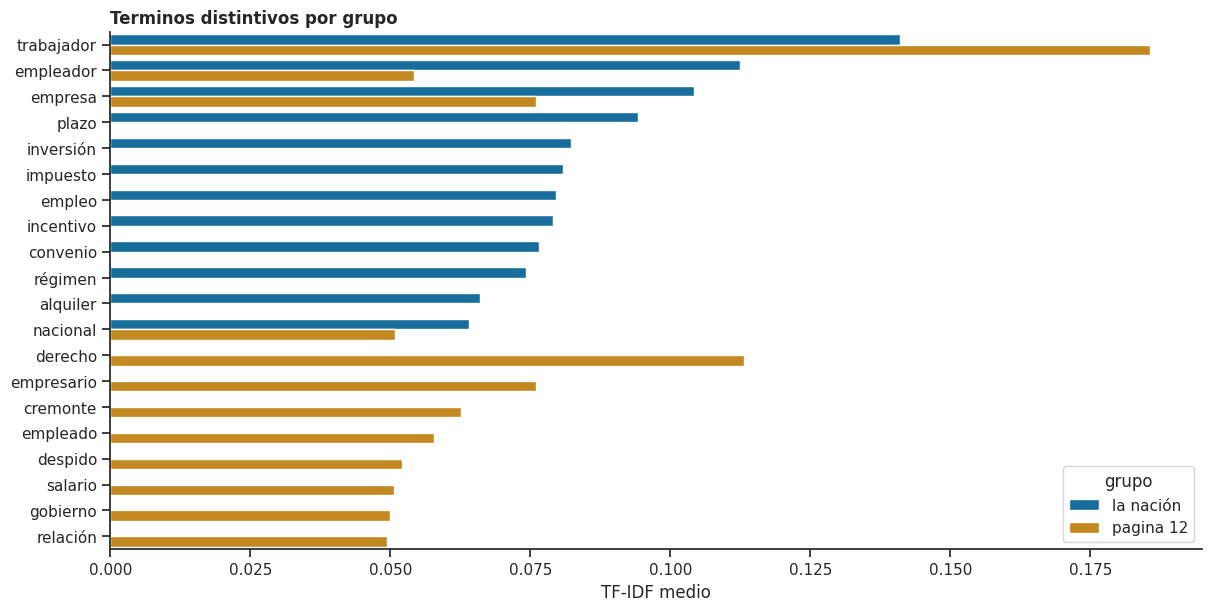

In [63]:
fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)

sns.barplot(
    data=top_tfidf,
    x="tfidf_medio",
    y="termino",
    hue="grupo",
    ax=ax,
)

ax.set_title("Terminos distintivos por grupo", loc="left", fontweight="bold")
ax.set_xlabel("TF-IDF medio")
ax.set_ylabel("")

sns.despine(ax=ax)
plt.show()

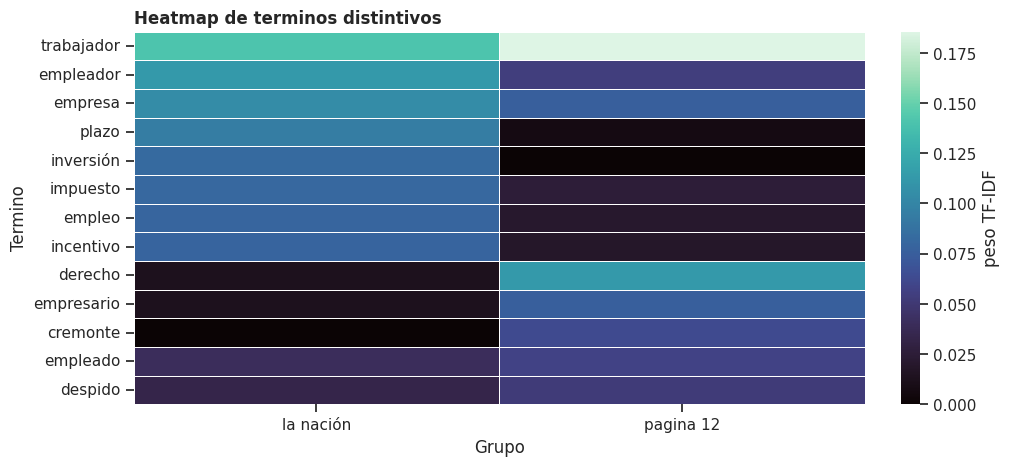

In [64]:
# Elegimos los primeros 8 terminos distintivos de cada grupo.
agrupado_top_tfidf = top_tfidf.groupby("grupo")
# 'head(8)' conserva los primeros 8 terminos de cada grupo.
top_ocho = agrupado_top_tfidf.head(8)
lista_terminos = top_ocho["termino"].tolist()

terminos_heatmap = []
for termino in lista_terminos:
    if termino not in terminos_heatmap:
        terminos_heatmap.append(termino)

# Volvemos a usar '.T' para que los terminos queden en el eje vertical.
matriz_heatmap = tabla_tfidf_grupos[terminos_heatmap].T

fig, ax = plt.subplots(figsize=(10, max(4, len(terminos_heatmap) * 0.35)), constrained_layout=True)

sns.heatmap(
    matriz_heatmap,
    cmap="mako",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "peso TF-IDF"},
    ax=ax,
)

ax.set_title("Heatmap de terminos distintivos", loc="left", fontweight="bold")
ax.set_xlabel("Grupo")
ax.set_ylabel("Termino")

plt.show()

Agreguen una celda Markdown nueva y comparen:

- que aparece como frecuente en ambos grupos;
- que aparece como distintivo en `TF-IDF`;
- que cambia entre volumen y especificidad.

## 8. Del patron al fragmento

La lectura distante orienta. La lectura cercana confirma, corrige o complica.

In [65]:
# Tomamos los 2 terminos mas distintivos de cada grupo.
agrupado_terminos = top_tfidf.groupby("grupo")
# 'head(2)' conserva los primeros 2 casos de cada grupo.
terminos_para_volver = agrupado_terminos.head(2)
# 'reset_index' recompone el indice para que la tabla quede limpia.
terminos_para_volver = terminos_para_volver.reset_index(drop=True)
display(terminos_para_volver)

,grupo,termino,tfidf_medio
0,la nación,trabajador,0.1411
1,la nación,empleador,0.1125
2,pagina 12,trabajador,0.1856
3,pagina 12,derecho,0.1131


In [66]:
def extraer_fragmentos(dataframe, grupo, termino, ventana=160, max_fragmentos=2):
    registros = []

    subconjunto = dataframe[dataframe[COLUMNA_GRUPO] == grupo]

    for fila in subconjunto.itertuples(index=False):
        texto_original = getattr(fila, COLUMNA_TEXTO)
        doc = nlp_ajustado(texto_original)

        for token in doc:
            coincide_lema = lema_ajustado(token) == termino
            coincide_forma = token.text.lower() == termino

            if coincide_lema or coincide_forma:
                inicio = max(0, token.idx - ventana)
                fin = min(len(texto_original), token.idx + len(token.text) + ventana)

                fragmento = texto_original[inicio:fin].strip()

                if inicio > 0:
                    fragmento = "..." + fragmento

                if fin < len(texto_original):
                    fragmento = fragmento + "..."

                registros.append({
                    "grupo": grupo,
                    "termino": termino,
                    "titulo": fila.titulo,
                    "fragmento": fragmento,
                })

                break

        if len(registros) >= max_fragmentos:
            break

    return registros

In [ ]:
registros_fragmentos = []

for fila in terminos_para_volver.itertuples(index=False):
    grupo = fila.grupo
    termino = fila.termino

    fragmentos_grupo = extraer_fragmentos(
        df,
        grupo,
        termino,
        ventana=VENTANA_FRAGMENTO,
        max_fragmentos=2,
    )

    registros_fragmentos.extend(fragmentos_grupo)

fragmentos = pd.DataFrame(registros_fragmentos)
display(fragmentos)

,grupo,termino,titulo,fragmento
0,la nación,trabajador,Se promulgó la reforma laboral: cuál es el impacto real en la vida de las empresas y de sus empleados,"...6 minutos de lectura' Este viernes se promulgó la reforma laboral, una iniciativa que buscará cambiar, por primera vez en décadas, la relación entre empr..."
1,la nación,trabajador,"Qué es la reforma laboral de Milei que aprobó el Senado: uno por uno, los principales cambios","...La versión que se convierte en ley es la que salió de la Cámara de Diputados la semana pasada, que excluye el artículo que imponía descuentos salariales ..."
2,la nación,empleador,Se promulgó la reforma laboral: cuál es el impacto real en la vida de las empresas y de sus empleados,...neficiados por la gran cantidad de mano de obra que requieren. Los cambios en las indemnizaciones y la creación de un sistema de cese laboral financiado ...
3,la nación,empleador,"Qué es la reforma laboral de Milei que aprobó el Senado: uno por uno, los principales cambios","...mentos. Se incorpora el concepto de “salario dinámico”, que puede ser acordado en los convenios colectivos, regionales o por empresa e incluso por decisi..."
4,pagina 12,trabajador,Todos los derechos con los que arrasa la reforma laboral de Milei,"La reforma laboral que el Gobierno impulsa con insistencia y que en la madrugada del jueves tuvo media sanción en el Senado, destruye el derecho de las y lo..."
5,pagina 12,trabajador,"Milei promulgó su reforma laboral: uno por uno, todos los derechos que pierden los trabajadores",El Gobierno nacional promulgó la ley de Reforma Laboral con la que quitó a los trabajadores cuantiosos derechos ganados durante décadas de conquistas obrera...
6,pagina 12,derecho,Todos los derechos con los que arrasa la reforma laboral de Milei,"La reforma laboral que el Gobierno impulsa con insistencia y que en la madrugada del jueves tuvo media sanción en el Senado, destruye el derecho de las y lo..."
7,pagina 12,derecho,"Milei promulgó su reforma laboral: uno por uno, todos los derechos que pierden los trabajadores",El Gobierno nacional promulgó la ley de Reforma Laboral con la que quitó a los trabajadores cuantiosos derechos ganados durante décadas de conquistas obrera...


Agreguen una celda Markdown nueva y expliquen:

- como aparece en contexto al menos un termino distintivo de cada grupo;
- que cambia cuando vuelven al fragmento;
- que no habrian visto si se quedaban solo con las tablas.

## 9. Cierre metodologico

Agreguen una celda Markdown nueva y respondan, de forma breve:

1. Que hallazgo creen que si pueden defender con evidencia.
2. Que habria salido mal si confiaban ciegamente en la primera salida de la maquina.
3. Que no se puede afirmar solo con estas representaciones.

## Rubrica

| Criterio | Peso |
|---|---:|
| Construccion y justificacion del corpus | 30% |
| Inspeccion y ajuste del pipeline con spaCy | 25% |
| Comparacion de stopwords y decisiones de preprocesamiento | 15% |
| Analisis comparativo con evidencia | 20% |
| Claridad, limites del metodo y reproducibilidad | 10% |

## Checklist final

- El corpus tiene 12 textos y 6 por grupo.
- La columna `grupo_comparacion` esta completa.
- Respondieron las preguntas metodologicas.
- Compararon stopwords de `spaCy` y `NLTK`.
- Hicieron al menos dos ajustes humanos del pipeline.
- Compararon `Bag of Words`, `TF-IDF` y bigramas.
- Incluyeron al menos dos visualizaciones analiticas legibles.
- Volvieron a fragmentos concretos del corpus.
- Cerraron con una conclusion interpretativa y metodologica.
- El notebook corre de principio a fin.